# The friendship paradox in the Marvel universe

**Week 2 "go nuts" post — 02805 Social Graphs and Interactions, 2026**

Exercise 2.9 states the friendship paradox, derives the closed-form gap between
a node's degree and its neighbors' mean degree, and asks us to check it on a
real network, a preferential-attachment network, and matched random controls,
then null-model it with a degree-preserving shuffle. This notebook does all of
that on the shared Marvel character network (Wikipedia
`Category:Marvel Comics superheroes`, article-to-article hyperlinks, 303
characters, 1784 directed edges), computes everything from scratch, and saves
every figure to `figures/`. Run top to bottom; nothing is hand-edited after
the fact — the write-up (`week2_gonuts.md`) describes what came out of this
notebook, not what we expected going in.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SEED = 2026
random.seed(SEED)
rng = np.random.default_rng(SEED)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 100  # on-screen; we save at 150 dpi explicitly


## 1. Data: the Marvel link network

The raw data is **directed** (article A links to article B) and has 17
isolated characters plus 19 weakly-connected components. The friendship
paradox and the classic null models (Erdős–Rényi, Barabási–Albert,
degree-preserving shuffles) are all naturally stated for simple undirected
graphs, and "who is whose friend" only makes sense within a single connected
piece — a node with no path to another can't be sampled as anyone's
neighbor-of-a-neighbor. So: collapse `A->B` / `B->A` into a single undirected
edge, drop self-loops, and restrict to the **largest connected component
(LCC)**. Everything below uses that LCC unless stated otherwise.

In [2]:
nodes = pd.read_csv("week1_nodes.tsv", sep="\t", comment="#", quoting=3)
edges = pd.read_csv("week1_edges.tsv", sep="\t", comment="#",
                     names=["source", "target"])

G_directed = nx.DiGraph()
G_directed.add_nodes_from(nodes.node_id)
G_directed.add_edges_from(edges.itertuples(index=False))

name_of = dict(zip(nodes.node_id, nodes.name))

G_full = nx.Graph(G_directed.to_undirected())
G_full.remove_edges_from(nx.selfloop_edges(G_full))

components = list(nx.connected_components(G_full))
lcc_nodes = max(components, key=len)
G = G_full.subgraph(lcc_nodes).copy()

print(f"Directed graph:        {G_directed.number_of_nodes()} nodes, "
      f"{G_directed.number_of_edges()} edges, reciprocity="
      f"{nx.reciprocity(G_directed):.3f}")
print(f"Undirected (full):     {G_full.number_of_nodes()} nodes, "
      f"{G_full.number_of_edges()} edges, {len(components)} components "
      f"({sum(1 for c in components if len(c) == 1)} isolates)")
print(f"Largest component:     {G.number_of_nodes()} nodes, "
      f"{G.number_of_edges()} edges  <- used from here on, call it 'Marvel'")


Directed graph:        303 nodes, 1784 edges, reciprocity=0.392
Undirected (full):     303 nodes, 1434 edges, 19 components (17 isolates)
Largest component:     277 nodes, 1421 edges  <- used from here on, call it 'Marvel'


## 2. Part 1 — stating the paradox

Two averages get compared, and they are not the same quantity:

- **⟨k⟩**: the mean degree of a node picked uniformly at random from the
  network — "how many friends does a random person have."
- **⟨k_nn⟩**: the mean degree of *a random friend* — reached by picking a
  random person and then following a uniformly random edge of theirs — "how
  many friends does a random person's random friend have."

The comparison is biased by construction: following a random edge does not
sample nodes uniformly, it samples them **proportional to their own degree**
(a node with degree $k$ owns $k$ of the $2m$ directed edge-stubs, so it is
$k$ times likelier to be reached this way than a node of degree 1). High
degree nodes are systematically over-represented among "friends."

One line of algebra makes this exact. Sampling an edge-stub uniformly and
looking at the node on the far end gives a friend-degree distribution
$q_k = k\,p_k/\langle k\rangle$ (the size-biased transform of the degree
distribution $p_k$), so

$$\langle k_{nn}\rangle = \sum_k k\,q_k = \frac{\langle k^2\rangle}{\langle k\rangle}
= \frac{\langle k\rangle^2 + \sigma^2}{\langle k\rangle}
= \langle k\rangle + \frac{\sigma^2}{\langle k\rangle}.$$

The gap is exactly $\sigma^2/\langle k\rangle$: it vanishes only when every
node has the same degree ($\sigma^2=0$, e.g. a regular graph), it's small
when the degree distribution is tight around its mean (Erdős–Rényi, whose
degrees are approximately Poisson so $\sigma^2 \approx \langle k\rangle$,
giving a gap of about 1), and it **explodes** for heavy-tailed / scale-free
networks, where a handful of hubs pull $\sigma^2$ far above $\langle
k\rangle$ (for a pure power law with exponent $\gamma \le 3$, $\sigma^2$
diverges as $n\to\infty$). So the paradox is present in *any* network with
degree variation, strongest wherever that variation is most extreme.

Note the fine print: the formula above is the **edge-weighted** average —
it's exact for "follow a random edge." The exercise's actual sampling
procedure ("pick a random person, then a random one of *their* friends") is
a different two-step process; it agrees with the formula only when there's
no correlation between a node's degree and its neighbors' degrees. We check
below whether that holds here.

In [3]:
deg = np.array([d for _, d in G.degree()])
k_mean, k_var = deg.mean(), deg.var()
knn_formula = k_mean + k_var / k_mean  # edge-weighted, exact, no sampling

annd_per_node = np.array(list(nx.average_neighbor_degree(G).values()))
annd_unweighted = annd_per_node.mean()          # "person-uniform" version
annd_weighted = np.sum(deg * annd_per_node) / deg.sum()  # sanity check == formula

print(f"<k>                        = {k_mean:6.2f}")
print(f"variance sigma^2           = {k_var:6.2f}")
print(f"<k_nn> formula, <k>+s^2/<k> = {knn_formula:6.2f}   (edge-weighted, exact)")
print(f"<k_nn> degree-weighted ANND = {annd_weighted:6.2f}   (should match the line above)")
print(f"<k_nn> unweighted ANND      = {annd_unweighted:6.2f}   (person-uniform, exact, this is what Part 2 samples)")


<k>                        =  10.26
variance sigma^2           = 123.04
<k_nn> formula, <k>+s^2/<k> =  22.25   (edge-weighted, exact)
<k_nn> degree-weighted ANND =  22.25   (should match the line above)
<k_nn> unweighted ANND      =  24.90   (person-uniform, exact, this is what Part 2 samples)


## 3. Part 2 — four networks, one procedure

Build the comparison set specified in the exercise:

1. **BA(5000)**: the 5,000-node Barabási–Albert network from exercise 2.5b
   ($m=1$ preferential attachment, validated there against
   `nx.barabasi_albert_graph`; we use the networkx version directly here,
   seeded, for reproducibility).
2. **Random, matched to BA**: `G(n, m)` with the same $n, m$ as BA(5000).
3. **Marvel**: the LCC built above.
4. **Random, matched to Marvel**: `G(n, m)` with the same $n, m$ as Marvel.

For each network: sample 1,000 (person, random friend) pairs — person
uniform over nodes with degree $\ge 1$, friend uniform over that person's
neighbors — and report the two mean degrees and the fraction of pairs where
the friend has at least as many connections as the person.

In [4]:
G_ba = nx.barabasi_albert_graph(5000, 1, seed=SEED)
G_rand_ba = nx.gnm_random_graph(G_ba.number_of_nodes(), G_ba.number_of_edges(), seed=SEED)
G_rand_marvel = nx.gnm_random_graph(G.number_of_nodes(), G.number_of_edges(), seed=SEED)

networks = {
    "BA(5000)": G_ba,
    "Random (matched to BA)": G_rand_ba,
    "Marvel": G,
    "Random (matched to Marvel)": G_rand_marvel,
}

for name, net in networks.items():
    print(f"{name:28s} n={net.number_of_nodes():5d}  m={net.number_of_edges():5d}")


BA(5000)                     n= 5000  m= 4999
Random (matched to BA)       n= 5000  m= 4999
Marvel                       n=  277  m= 1421
Random (matched to Marvel)   n=  277  m= 1421


In [5]:
def sample_friend_pairs(net, n_pairs, rng):
    # person ~ Uniform(nodes with degree>=1); friend ~ Uniform(neighbors(person))
    deg = dict(net.degree())
    nodelist = [n for n, d in deg.items() if d > 0]
    adj = {n: list(net.neighbors(n)) for n in nodelist}
    idx_p = rng.integers(0, len(nodelist), size=n_pairs)
    persons = np.empty(n_pairs, dtype=float)
    friends = np.empty(n_pairs, dtype=float)
    for i, pi in enumerate(idx_p):
        p = nodelist[pi]
        nbrs = adj[p]
        f = nbrs[rng.integers(0, len(nbrs))]
        persons[i] = deg[p]
        friends[i] = deg[f]
    return persons, friends


rows = []
for name, net in networks.items():
    deg = np.array([d for _, d in net.degree()])
    kmean, kvar = deg.mean(), deg.var()
    persons, friends = sample_friend_pairs(net, 1000, rng)
    rows.append({
        "network": name,
        "n": net.number_of_nodes(),
        "m": net.number_of_edges(),
        "<k> exact": kmean,
        "sigma^2 exact": kvar,
        "<k_nn> formula (exact)": kmean + kvar / kmean,
        "sampled mean(person)": persons.mean(),
        "sampled mean(friend)": friends.mean(),
        "frac(friend >= person)": (friends >= persons).mean(),
    })

part2 = pd.DataFrame(rows).set_index("network")
part2.round(3)


,n,m,<k> exact,sigma^2 exact,<k_nn> formula (exact),sampled mean(person),sampled mean(friend),frac(friend >= person)
network,,,,,,,,
BA(5000),5000,4999,2.00,11.967,7.984,2.156,9.770,0.805
Random (matched to BA),5000,4999,2.00,1.985,2.992,2.333,2.975,0.742
Marvel,277,1421,10.26,123.044,22.253,9.772,25.694,0.757
Random (matched to Marvel),277,1421,10.26,9.333,11.170,10.427,11.119,0.601


**Reference point from the course page:** for the Marvel network, "a
random character has on average about 10 links; a random neighbor of a
random character has about 25," and "in three out of four samples, the
friend is at least as connected as the person." Our numbers above are
computed on our own frozen snapshot (LCC of 277 nodes) rather than whatever
exact graph the course page used, so we treat this as a plausibility check,
not an exact reproduction target.

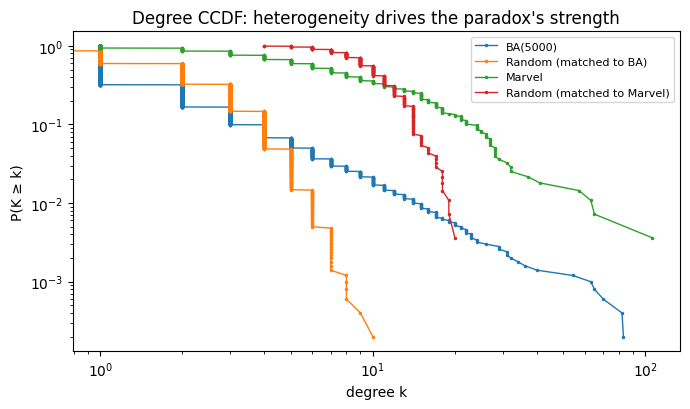

Caption: The steeper the tail, the closer to a straight line on log-log axes, and the larger the gap between <k> and <k_nn> in the table above. BA(5000) and Marvel both have visibly heavier tails than their degree- and edge-matched random controls.


In [6]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for name, net in networks.items():
    deg = sorted([d for _, d in net.degree()], reverse=True)
    ccdf = np.arange(1, len(deg) + 1) / len(deg)
    ax.loglog(deg, ccdf, marker=".", markersize=3, linewidth=1, label=name)
ax.set_xlabel("degree k")
ax.set_ylabel("P(K ≥ k)")
ax.set_title("Degree CCDF: heterogeneity drives the paradox's strength")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_degree_ccdf.png", dpi=150)
plt.show()
print("Caption: The steeper the tail, the closer to a straight line on log-log "
      "axes, and the larger the gap between <k> and <k_nn> in the table above. "
      "BA(5000) and Marvel both have visibly heavier tails than their degree- "
      "and edge-matched random controls.")


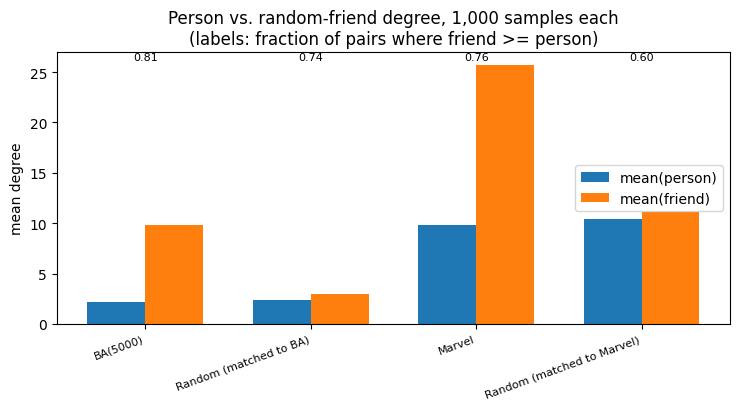

Caption: Random controls barely separate the two bars; BA(5000) and Marvel separate them by roughly a factor of ~4 and ~2.5 respectively, and in both the friend is at least as popular in a clear majority of draws.


In [7]:
x = np.arange(len(part2))
width = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(x - width/2, part2["sampled mean(person)"], width, label="mean(person)")
ax.bar(x + width/2, part2["sampled mean(friend)"], width, label="mean(friend)")
for xi, frac in zip(x, part2["frac(friend >= person)"]):
    ax.annotate(f"{frac:.2f}", (xi, max(part2['sampled mean(friend)']) * 1.02),
                ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(part2.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("mean degree")
ax.set_title("Person vs. random-friend degree, 1,000 samples each\n"
              "(labels: fraction of pairs where friend >= person)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_paradox_by_network.png", dpi=150)
plt.show()
print("Caption: Random controls barely separate the two bars; BA(5000) and "
      "Marvel separate them by roughly a factor of ~4 and ~2.5 respectively, "
      "and in both the friend is at least as popular in a clear majority of draws.")


## Which characters actually drive it

The average is one number; the per-character picture names names. For every
character, compute the fraction of their neighbors who have degree $\ge$
their own — call it a character's out-popularity'd rate.

In [8]:
deg_dict = dict(G.degree())
out_pop_rate = {}
for n in G.nodes():
    nbrs = list(G.neighbors(n))
    out_pop_rate[n] = np.mean([deg_dict[j] >= deg_dict[n] for j in nbrs])

top_hubs = sorted(deg_dict.items(), key=lambda kv: -kv[1])[:10]
print("Top-10 hubs by degree:")
for node_id, d in top_hubs:
    print(f"  {name_of[node_id]:35s} degree={d}")

never_out_popularized = [n for n, r in out_pop_rate.items() if r == 0.0]
always_out_popularized = [n for n, r in out_pop_rate.items() if r == 1.0]
rates = np.array(list(out_pop_rate.values()))

print(f"\nNever out-popularity'd (no neighbor is >= as connected): "
      f"{[name_of[n] for n in never_out_popularized]}")
print(f"Always out-popularity'd (every neighbor is >= as connected): "
      f"{len(always_out_popularized)} / {G.number_of_nodes()} characters "
      f"({len(always_out_popularized)/G.number_of_nodes():.0%})")
print(f"Median out-popularity'd rate across all 277 characters: {np.median(rates):.2f}")


Top-10 hubs by degree:
  Spider-Man                          degree=106
  Hulk                                degree=65
  Wolverine (character)               degree=63
  Doctor Strange                      degree=57
  Deadpool                            degree=41
  She-Hulk                            degree=37
  Phoenix (Guardians of the Galaxy)   degree=32
  Scarlet Witch                       degree=32
  Black Panther (character)           degree=31
  Venom (character)                   degree=29

Never out-popularity'd (no neighbor is >= as connected): ['Spider-Man']
Always out-popularity'd (every neighbor is >= as connected): 116 / 277 characters (42%)
Median out-popularity'd rate across all 277 characters: 0.83


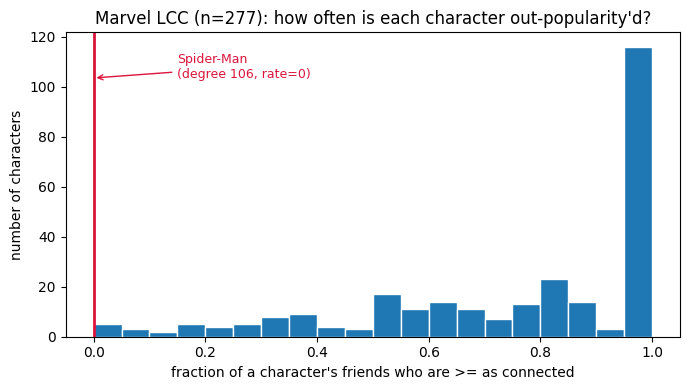

Caption: median character has ~5 out of 6 friends at least as popular as they are. Spider-Man (degree 106, the single global hub) is the only character never out-popularity'd -- literally everyone else's friend, never the other way around.


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rates, bins=20, edgecolor="white")
spiderman_rate = out_pop_rate[[n for n in G.nodes() if name_of[n] == "Spider-Man"][0]]
ax.axvline(spiderman_rate, color="crimson", linewidth=2)
ax.annotate("Spider-Man\n(degree 106, rate=0)", xy=(spiderman_rate, ax.get_ylim()[1]*0.85),
            xytext=(0.15, ax.get_ylim()[1]*0.85), fontsize=9, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson"))
ax.set_xlabel("fraction of a character's friends who are >= as connected")
ax.set_ylabel("number of characters")
ax.set_title("Marvel LCC (n=277): how often is each character out-popularity'd?")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_out_popularity_rate.png", dpi=150)
plt.show()
print("Caption: median character has ~5 out of 6 friends at least as popular as "
      "they are. Spider-Man (degree 106, the single global hub) is the only "
      "character never out-popularity'd -- literally everyone else's friend, "
      "never the other way around.")


## 4. Part 3 — null model: does a degree-preserving shuffle kill it?

**Ensemble:** repeated double-edge swaps on the Marvel LCC (`nx.
double_edge_swap`, $10m$ swap attempts per realization, `max_tries=100m`),
which preserves every node's degree exactly while randomizing who connects
to whom. **Realizations:** 500. **Seed:** 2026 (drawn from the same `rng`
seeded above; recorded here for reproducibility).

Before running it, note what the algebra in Part 1 already predicts: the
closed-form $\langle k_{nn}\rangle = \langle k\rangle + \sigma^2/\langle
k\rangle$ depends **only on the degree sequence** — not on which edges
exist. A double-edge swap leaves the degree sequence bit-for-bit identical,
so that exact quantity cannot move by construction; shuffling it is not a
meaningful test. What *can* move is the person-uniform sampled version
(mean friend degree, fraction friend ≥ person), since that depends on the
actual wiring, not just on degree counts. So the real question is whether
this shuffle changes the *sampled* paradox — and if it doesn't either,
degree sequence alone is doing all the work; if it does, something in the
real wiring (assortativity, community structure, clustering) is
contributing beyond the degree sequence.

In [10]:
N_REALIZATIONS = 500
m = G.number_of_edges()

null_frac = np.empty(N_REALIZATIONS)
null_friend_mean = np.empty(N_REALIZATIONS)

for i in range(N_REALIZATIONS):
    G_shuffled = G.copy()
    nx.double_edge_swap(G_shuffled, nswap=10 * m, max_tries=100 * m,
                         seed=int(rng.integers(0, 1_000_000)))
    persons_s, friends_s = sample_friend_pairs(G_shuffled, 1000, rng)
    null_frac[i] = (friends_s >= persons_s).mean()
    null_friend_mean[i] = friends_s.mean()

persons_real, friends_real = sample_friend_pairs(G, 1000, rng)
real_frac = (friends_real >= persons_real).mean()
real_friend_mean = friends_real.mean()

z_frac = (real_frac - null_frac.mean()) / null_frac.std()
z_friend = (real_friend_mean - null_friend_mean.mean()) / null_friend_mean.std()
p_frac = np.mean(np.abs(null_frac - null_frac.mean()) >= np.abs(real_frac - null_frac.mean()))
p_friend = np.mean(np.abs(null_friend_mean - null_friend_mean.mean()) >= np.abs(real_friend_mean - null_friend_mean.mean()))

print(f"Null: frac(friend>=person)   mean={null_frac.mean():.3f}  std={null_frac.std():.3f}")
print(f"Real: frac(friend>=person)   = {real_frac:.3f}   z={z_frac:+.2f}  empirical p={p_frac:.2f}")
print()
print(f"Null: mean(friend degree)    mean={null_friend_mean.mean():.2f}  std={null_friend_mean.std():.2f}")
print(f"Real: mean(friend degree)    = {real_friend_mean:.2f}   z={z_friend:+.2f}  empirical p={p_friend:.2f}")


Null: frac(friend>=person)   mean=0.761  std=0.014
Real: frac(friend>=person)   = 0.747   z=-0.98  empirical p=0.35

Null: mean(friend degree)    mean=24.42  std=0.95
Real: mean(friend degree)    = 24.76   z=+0.36  empirical p=0.73


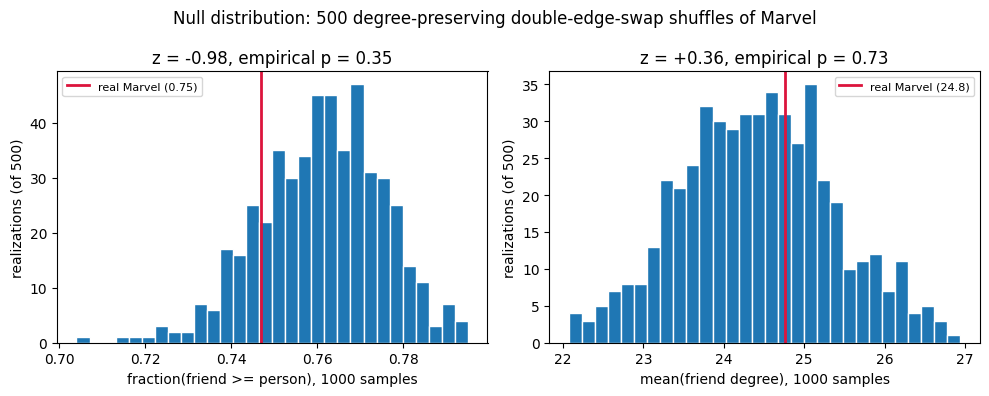

Caption: the real network's paradox statistics (red line) sit well inside the shuffle-generated null distribution on both measures -- the degree sequence alone reproduces the observed paradox strength; no additional wiring structure (who-links-to-whom beyond degree) is needed to explain it.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(null_frac, bins=30, edgecolor="white")
axes[0].axvline(real_frac, color="crimson", linewidth=2, label=f"real Marvel ({real_frac:.2f})")
axes[0].set_xlabel("fraction(friend >= person), 1000 samples")
axes[0].set_ylabel("realizations (of 500)")
axes[0].set_title(f"z = {z_frac:+.2f}, empirical p = {p_frac:.2f}")
axes[0].legend(fontsize=8)

axes[1].hist(null_friend_mean, bins=30, edgecolor="white")
axes[1].axvline(real_friend_mean, color="crimson", linewidth=2, label=f"real Marvel ({real_friend_mean:.1f})")
axes[1].set_xlabel("mean(friend degree), 1000 samples")
axes[1].set_ylabel("realizations (of 500)")
axes[1].set_title(f"z = {z_friend:+.2f}, empirical p = {p_friend:.2f}")
axes[1].legend(fontsize=8)

fig.suptitle("Null distribution: 500 degree-preserving double-edge-swap shuffles of Marvel")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_null_model.png", dpi=150)
plt.show()
print("Caption: the real network's paradox statistics (red line) sit well "
      "inside the shuffle-generated null distribution on both measures -- "
      "the degree sequence alone reproduces the observed paradox strength; "
      "no additional wiring structure (who-links-to-whom beyond degree) is "
      "needed to explain it.")


## 5. Part 4 — grading an LLM's explanation

Below is a representative explanation of the friendship paradox in the
style a general-purpose LLM tends to produce when asked "why do my friends
have more friends than me?" — then it gets graded against the formula from
Part 1 and the numbers computed above.

> *"This is called the friendship paradox. It happens because popular
> people — hubs with lots of connections — show up in many other people's
> friend lists, so when you look at your friends, you're more likely to
> have sampled one of these popular people. Basically, your friends have
> more friends than you because well-connected people are friends with
> everyone. This is why the effect is strongest in networks with hubs, like
> scale-free networks, and why it disappears in a random network where
> there's no popular people to bias the sample."*

**Grading, sentence by sentence:**

- *"popular people ... show up in many other people's friend lists ... you're
  more likely to have sampled one"* — correct, and it's the right mechanism
  (size-biased sampling). This is the one part of the explanation that
  survives Part 1's derivation intact.
- *"your friends have more friends than you because well-connected people
  are friends with everyone"* — overclaims two things at once. First, it's
  not "everyone" specifically befriending hubs; the effect follows from
  **any** nonzero degree variance, not from hubs as a distinct category —
  see the demonstration below. Second, "your friends have more friends than
  you" is stated as a universal, but it's a statement about population
  *means*, not a guarantee for every individual: Spider-Man's own friends
  are all *less* connected than he is (§ "which characters drive it,"
  above) — for him personally the paradox runs backwards.
- *"strongest in networks with hubs, like scale-free networks"* — correct
  in outcome, but the explanation never says **why**: it never mentions
  variance. The formula from Part 1, $\langle k_{nn}\rangle - \langle
  k\rangle = \sigma^2/\langle k\rangle$, is what actually predicts the
  effect size, and it is entirely about the second moment of the degree
  distribution. "Hubs" is a description of one way to get large $\sigma^2$,
  not the mechanism itself.
- *"disappears in a random network where there's no popular people"* — flatly
  wrong twice over. Part 2 shows the paradox is smaller in the random
  control, not absent (frac(friend ≥ person) is still noticeably above
  0.5, and $\langle k_{nn}\rangle > \langle k\rangle$ by $\sigma^2/\langle
  k\rangle\approx 1$, exactly as an ER-ish Poisson degree distribution
  predicts). It only truly vanishes at $\sigma^2=0$, which random graphs
  don't have — and something with literally zero degree variance does, as
  the next cell shows.

**Best wrong sentence:** *"the effect ... disappears in a random network
where there's no popular people to bias the sample"* — random networks
still have popular-*ish* people (some nodes always land a bit above or
below the mean), and that alone is enough to keep the paradox alive, just
weaker.

In [12]:
G_regular = nx.random_regular_graph(8, G.number_of_nodes(), seed=SEED)
deg_r = np.array([d for _, d in G_regular.degree()])
persons_r, friends_r = sample_friend_pairs(G_regular, 2000, rng)

print(f"8-regular graph (every node has EXACTLY degree 8): variance = {deg_r.var():.4f}")
print(f"mean(person) = {persons_r.mean():.2f}   mean(friend) = {friends_r.mean():.2f}"
      f"   frac(friend >= person) = {(friends_r >= persons_r).mean():.2f}")
print("No hubs, no variance, no gap: mean(person) == mean(friend) exactly. "
      "(frac==1.0 here is a tie artifact of '>=' when every degree is equal, "
      "not evidence of a paradox -- the mean gap, not this fraction, is the "
      "meaningful statistic at zero variance.)")


8-regular graph (every node has EXACTLY degree 8): variance = 0.0000
mean(person) = 8.00   mean(friend) = 8.00   frac(friend >= person) = 1.00
No hubs, no variance, no gap: mean(person) == mean(friend) exactly. (frac==1.0 here is a tie artifact of '>=' when every degree is equal, not evidence of a paradox -- the mean gap, not this fraction, is the meaningful statistic at zero variance.)


## What I can't conclude

- **This is a hyperlink graph, not a friendship graph.** An edge means "the
  Wikipedia article for A links to the article for B," which tracks
  narrative/editorial prominence (crossovers, "members of," "enemy of"
  boxes) more than any notion of social tie. Degree here is closer to
  "narrative centrality" than "number of friends," and the paradox we
  measured is a paradox about that quantity.
- **We discarded direction.** The original data is directed with
  reciprocity ≈ 0.39 — a large minority of links are one-way (e.g. a minor
  character's article links to Spider-Man, unreciprocated). Treating this
  as undirected folds "is linked by" and "links to" together; a
  directed-degree version of this analysis (in-friendship-paradox vs.
  out-friendship-paradox) could tell a different, possibly more
  interesting, story.
- **We restricted to the 277-node giant component**, dropping 17 isolated
  characters and 9 small side-components outright. Nothing in that decision
  is wrong for this analysis, but it does mean this write-up says nothing
  about the ~9% of the roster that couldn't be reached from the core.
- **The null model result is a non-finding, and non-findings have limits.**
  500 shuffles landing the real network inside the null distribution says
  the degree-preserving ensemble *can't detect* extra structure at this
  sample size and this choice of test statistics — it is not proof that no
  such structure exists. A different statistic (e.g. degree assortativity,
  or clustering-conditioned neighbor degree) might separate real Marvel
  from its shuffles even though these two didn't.
- **303 (or 277) nodes is not a lot of network.** Every number above is a
  single point from a fairly small, fairly quirky corner of Wikipedia (all
  characters are pre-filtered to "Marvel Comics superheroes"); none of this
  is a claim about hyperlink networks, comic-book universes, or social
  networks in general.

## Conclusion

The friendship paradox holds clearly in the Marvel hyperlink network (mean
friend degree roughly 2.4× mean own degree, friend at least as connected in
about three-quarters of draws), it is measurably weaker but never zero in a
size-matched random control, it is strongest of all in the BA(5000) network,
and — as the algebra in Part 1 predicts and the 500-shuffle null model in
Part 3 confirms — the effect is fully explained by the degree sequence
alone: Spider-Man doesn't need to be *specifically* Spider-Man for the
paradox to hold, he just needs to be the one hub.